Introduction to pytorch.

In [2]:
!pip install torch

  Using cached filelock-3.19.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached fsspec-2025.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 MB 16.0 MB/s eta 0:00:0000:0100:01
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached filelock-3.19.1-py3-none-any.whl (15 kB)
Using cached fsspec-2025.9.0-py3-none-any.whl (199 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.5 MB/s eta 0:00:00a 0:00:01
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)


In [3]:
import torch

In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CPU


In [ ]:
import torch
print(torch.backends.mps.is_available())

True


In [6]:
import torch.nn as nn

In [7]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.linear = nn.Linear(2,1)
        # self.relu = nn.ReLU()
        # self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.linear(x)
        # out = self.relu(out)
        # out = self.fc2(out)
        return out
model = SimpleNN().to(device)
print(model)

SimpleNN(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)


In [9]:
xt = torch.randn(2,2).to(device)
print(xt)

tensor([[ 1.8421, -0.2095],
        [ 0.9891,  0.9376]])


In [10]:
model.parameters

<bound method Module.parameters of SimpleNN(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)>

In [11]:
for epoch in range(5):
    out = model(xt)
    print(f"Epoch {epoch+1}, Output: {out.detach().cpu().numpy()}")

Epoch 1, Output: [[-0.2458778]
 [-0.8668685]]
Epoch 2, Output: [[-0.2458778]
 [-0.8668685]]
Epoch 3, Output: [[-0.2458778]
 [-0.8668685]]
Epoch 4, Output: [[-0.2458778]
 [-0.8668685]]
Epoch 5, Output: [[-0.2458778]
 [-0.8668685]]


In [13]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=10000, n_features=1, noise=2.5, n_informative=1, n_targets=1 ,random_state=42)

In [14]:
print(type(X), type(y))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [17]:
print(X.shape)
print(y.shape)

(10000, 1)
(10000,)


In [19]:
import numpy as np
y = np.expand_dims(y, axis=1)
print(y.shape)

(10000, 1)


In [20]:
n_inputs = X.shape[1]
n_outputs = y.shape[1]

In [21]:
X = torch.tensor(X, dtype=torch.float32).to(device)
y = torch.tensor(y, dtype=torch.float32).to(device)

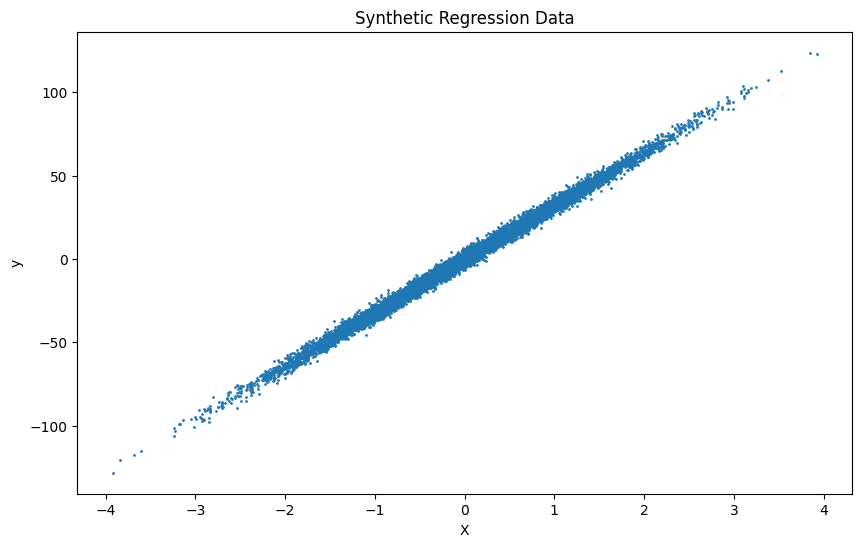

In [22]:
plt.figure(figsize=(10,6))
plt.scatter(X.cpu(), y.cpu(), s=1)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Regression Data")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
X_train = X_train.float().to(device)
y_train = y_train.float().to(device)
X_test = X_test.float().to(device)
y_test = y_test.float().to(device)

In [31]:
def pytorch_linear_regression(X_train, y_train, X_test, y_test, n_inputs, n_outputs, learning_rate=0.01, n_epochs=100):
    model = nn.Linear(n_inputs, n_outputs).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    train_losses = []
    test_losses = []

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)
            test_losses.append(test_loss.item())

        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{n_epochs}], Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

    return model, train_losses, test_losses

Mini Batch Gradient Descent

In [32]:
from torch.utils.data import DataLoader, TensorDataset
train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

In [34]:
model = nn.Linear(n_inputs, n_outputs).to(device)
print(model.weight, model.bias)

Parameter containing:
tensor([[-0.9325]], requires_grad=True) Parameter containing:
tensor([-0.9704], requires_grad=True)


In [36]:
import torch.nn.functional as F
loss_fn = F.mse_loss


In [37]:
optim = torch.optim.SGD(model.parameters(), lr=0.01)

In [38]:
epoch = 100
loss = []

for epoch in range(1, epoch +1):
    for xb, yb in train_loader:
        y_pred = model(xb)
        l = loss_fn(y_pred, yb)
        l.backward()
        optim.step()
        optim.zero_grad()
    loss.append(l.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {l.item()}")

Epoch 10, Loss: 4.194502353668213
Epoch 20, Loss: 6.150692939758301
Epoch 30, Loss: 7.936841011047363
Epoch 40, Loss: 10.302292823791504
Epoch 50, Loss: 6.219816207885742
Epoch 60, Loss: 4.770631790161133
Epoch 70, Loss: 5.676247596740723
Epoch 80, Loss: 5.748136520385742
Epoch 90, Loss: 7.059451103210449
Epoch 100, Loss: 6.846917152404785


In [39]:
torch.save(model.state_dict(), 'linear_regression_model.pth')

In [42]:
model = torch.load('linear_regression_model.pth')